In [1]:
%pip install --quiet -U python-dotenv pydantic-ai opencv-python-headless supervision ultralytics

import os
from pathlib import Path
import nest_asyncio; nest_asyncio.apply()

# Download data files if not already present (e.g. on Colab)
if not Path("data").exists():
    import zipfile, urllib.request
    url = "https://github.com/jsoma/workshop-ai-images-video/raw/main/docs/nicar-2026/06-tracking-data.zip"
    print("Downloading data...")
    urllib.request.urlretrieve(url, "_data.zip")
    with zipfile.ZipFile("_data.zip") as zf:
        zf.extractall("data")
    Path("_data.zip").unlink()
    print("Done!")

# Paste API keys here or leave empty for .env / Colab secrets
api_keys = {"OPENAI_API_KEY": "", "GOOGLE_API_KEY": ""}
os.environ.update({k: v for k, v in api_keys.items() if v})
try:
    from google.colab import userdata
    for key in api_keys:
        try: os.environ.setdefault(key, userdata.get(key))
        except Exception: pass
except ImportError:
    from dotenv import load_dotenv; load_dotenv()

DATA = Path("data")
Path("outputs").mkdir(exist_ok=True)


/Users/soma/Library/CloudStorage/Dropbox/Soma/Curriculum/2026-nicar/01-fri-analyzing-images-videos-ai/ai-images-video/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


# Bonus: Tracking & Counting

Want to reproduce [this Bloomberg piece about congestion pricing?](https://www.bloomberg.com/graphics/2025-nyc-congestion-pricing-week-one-traffic-mix-shifts/) We can get about 60% of the way there!

The library doing the heavy lifting here is [supervision](https://supervision.roboflow.com/), which handles tracking, drawing, and counting on top of any object detection model. It's fantastic.


In [2]:
from IPython.display import Video
Video("data/istockphoto-534232220-640_adpp_is.mp4", embed=True, width=500)


## Step 1: Detect

First, we just detect objects in a single frame. YOLO finds the cars, supervision draws the boxes.


**`tracking/detect.py`** — Detect objects in a single video frame with YOLO


In [3]:
import warnings, logging, os
warnings.filterwarnings("ignore")
os.dup2(os.open(os.devnull, os.O_WRONLY), 2)
logging.disable(logging.ERROR)
os.environ["TQDM_DISABLE"] = "1"


Found 6 objects


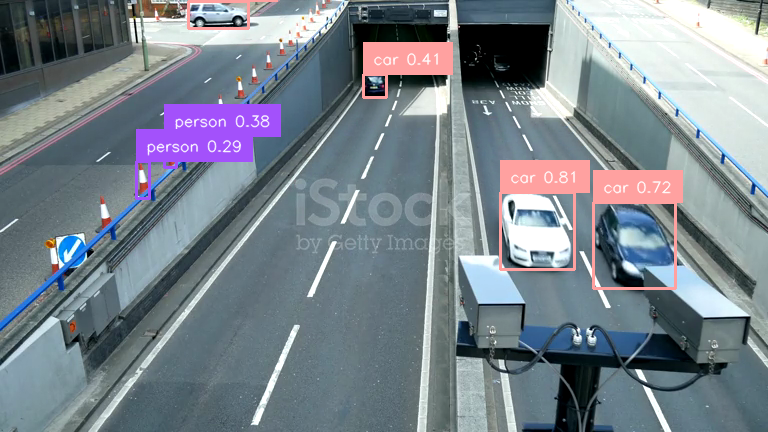

In [ ]:
from pathlib import Path
from PIL import Image
import cv2
import supervision as sv
from ultralytics import YOLO

DATA = Path("data")
VIDEO = DATA / "istockphoto-534232220-640_adpp_is.mp4"

model = YOLO("yolo26n")
cap = cv2.VideoCapture(str(VIDEO))
cap.set(cv2.CAP_PROP_POS_FRAMES, 50)
ret, frame = cap.read()
cap.release()

detections = sv.Detections.from_ultralytics(model(frame, verbose=False)[0])
labels = [f"{model.names[int(c)]} {conf:.2f}" for c, conf in zip(detections.class_id, detections.confidence)]
annotated = sv.BoxAnnotator().annotate(frame.copy(), detections)
annotated = sv.LabelAnnotator().annotate(annotated, detections, labels=labels)

print(f"Found {len(detections)} objects")
Image.fromarray(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))


## Step 2: Track

Now we add **tracking**. ByteTrack links detections across frames — "that's car #7, same one from 3 seconds ago." Each object gets a unique ID and a motion trail.


**`tracking/track.py`** — Track objects across video frames with YOLO + ByteTrack


In [4]:
import warnings, logging, os
warnings.filterwarnings("ignore")
os.dup2(os.open(os.devnull, os.O_WRONLY), 2)
logging.disable(logging.ERROR)
os.environ["TQDM_DISABLE"] = "1"


In [5]:
from pathlib import Path
import cv2
import supervision as sv
import ipywidgets as widgets
from IPython.display import display
from ultralytics import YOLO

DATA = Path("data")
VIDEO = DATA / "istockphoto-534232220-640_adpp_is.mp4"
MAX_FRAMES = 100

model = YOLO("yolo26n")
tracker = sv.ByteTrack()
smoother = sv.DetectionsSmoother()
box_ann = sv.BoxAnnotator()
label_ann = sv.LabelAnnotator()
trace_ann = sv.TraceAnnotator()

image_widget = widgets.Image(format='jpeg')
display(image_widget)

cap = cv2.VideoCapture(str(VIDEO))
frame_count = 0
while cap.isOpened() and frame_count < MAX_FRAMES:
    ret, frame = cap.read()
    if not ret:
        break
    detections = sv.Detections.from_ultralytics(model(frame, verbose=False)[0])
    detections = tracker.update_with_detections(detections)
    detections = smoother.update_with_detections(detections)
    labels = [f"#{tid} {model.names[int(c)]}" for tid, c in zip(detections.tracker_id, detections.class_id)] if detections.tracker_id is not None else []
    annotated = box_ann.annotate(frame.copy(), detections)
    annotated = trace_ann.annotate(annotated, detections)
    annotated = label_ann.annotate(annotated, detections, labels=labels)
    _, buf = cv2.imencode('.jpg', annotated)
    image_widget.value = buf.tobytes()
    frame_count += 1
cap.release()

print(f"Tracked {frame_count} frames")


Image(value=b'', format='jpeg')

Tracked 100 frames


## Step 3: Count

Draw a virtual line across the road. Every time a tracked object crosses it, the counter ticks up. Think: counting cars at an intersection, people entering a building, boats passing under a bridge.


**`tracking/count.py`** — Count objects crossing a line with YOLO + ByteTrack + LineZone


In [6]:
import warnings, logging, os
warnings.filterwarnings("ignore")
os.dup2(os.open(os.devnull, os.O_WRONLY), 2)
logging.disable(logging.ERROR)
os.environ["TQDM_DISABLE"] = "1"


In [7]:
from pathlib import Path
import cv2
import supervision as sv
import ipywidgets as widgets
from IPython.display import display
from ultralytics import YOLO

DATA = Path("data")
VIDEO = DATA / "istockphoto-534232220-640_adpp_is.mp4"

model = YOLO("yolo26n")
tracker = sv.ByteTrack()
smoother = sv.DetectionsSmoother()
box_ann = sv.BoxAnnotator()
label_ann = sv.LabelAnnotator()
trace_ann = sv.TraceAnnotator()
line_zone = sv.LineZone(start=sv.Point(200, 175), end=sv.Point(700, 175))
line_ann = sv.LineZoneAnnotator(text_thickness=1)

image_widget = widgets.Image(format='jpeg')
display(image_widget)

cap = cv2.VideoCapture(str(VIDEO))
frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    detections = sv.Detections.from_ultralytics(model(frame, verbose=False)[0])
    detections = tracker.update_with_detections(detections)
    detections = smoother.update_with_detections(detections)
    line_zone.trigger(detections)
    labels = [f"#{tid} {model.names[int(c)]}" for tid, c in zip(detections.tracker_id, detections.class_id)] if detections.tracker_id is not None else []
    annotated = box_ann.annotate(frame.copy(), detections)
    annotated = trace_ann.annotate(annotated, detections)
    annotated = label_ann.annotate(annotated, detections, labels=labels)
    annotated = line_ann.annotate(annotated, line_counter=line_zone)
    _, buf = cv2.imencode('.jpg', annotated)
    image_widget.value = buf.tobytes()
    frame_count += 1
cap.release()

print(f"Processed {frame_count} frames")
print(f"Crossed IN: {line_zone.in_count} | OUT: {line_zone.out_count}")


Image(value=b'', format='jpeg')

Processed 625 frames
Crossed IN: 20 | OUT: 20


The actual count is around 20 in and 20 out. How close did we get?

## ...but can Gemini just do this?

We've been using Gemini for all sorts of stuff. Let's see if it can count cars in the video. We upload the same clip and ask it to count.


**`tracking/gemini-count.py`** — Ask Gemini to count cars in a video — spoiler: it struggles


In [8]:
import warnings, logging, os
warnings.filterwarnings("ignore")
os.dup2(os.open(os.devnull, os.O_WRONLY), 2)
logging.disable(logging.ERROR)
os.environ["TQDM_DISABLE"] = "1"


In [ ]:
import time
from pathlib import Path

from pydantic_ai import Agent, VideoUrl
from pydantic_ai.providers.google import GoogleProvider

DATA = Path("data")
VIDEO = DATA / "istockphoto-534232220-640_adpp_is.mp4"
MODEL = "google-gla:gemini-2.5-flash"

provider = GoogleProvider()
video_file = provider.client.files.upload(file=str(VIDEO))

while video_file.state.name == "PROCESSING":
    time.sleep(5)
    video_file = provider.client.files.get(name=video_file.name)

agent = Agent(MODEL)
result = agent.run_sync([
    "Watch this traffic video carefully. Count the exact number of cars "
    "that enter the left tunnel and the number that exit the right tunnel.",
    VideoUrl(url=video_file.uri, media_type=video_file.mime_type),
])
print(result.output)


Here's the count from the video:

*   Number of cars that enter the left tunnel: **21**
*   Number of cars that exit the right tunnel: **24**


**The answer is: no, not really.** LLMs are bad at counting things in video – they're great at *vibes*, they're great as yes/no, but measurements are where things get iffy (at least at the moment). This is exactly the kind of task where boring traditional computer vision (detection + tracking + counting) beats the "just ask AI" approach.

## Going further

What if you don't just want *cars*, though — you want to be Bloomberg, and spot taxis and box trucks and commercial vehicles! While you might try to find a model that does that, you can also **train your own** with a handful of labeled images.

If you're interested in going to the next level, check out [the Roboflow docs](https://blog.roboflow.com/getting-started-with-roboflow/) — you can train a custom YOLO model, swap it in, and everything else stays the same.
